
# 02425 Diffusion and stochastich differential equations


## WEEK 3

In [43]:
import numpy as np
import random
from numpy import random
from matplotlib import pyplot as plt
import scipy.stats as stats


In this exercises we will look at the Brownian motion phenomena. Here we will study some of its charachteristics.

### Exercise 1

In [44]:
def Brownian(partition):

    BrownianMotion = np.array([])

    for i in range(len(partition)):

        if partition[i] == 0:
            BrownianMotion = np.append(BrownianMotion, 0)
        if partition[i] != 0:
            BrownianMotion = np.append(BrownianMotion, random.normal(loc=BrownianMotion[-1], scale=np.sqrt(partition[i]-partition[i-1])))

    return BrownianMotion

### Exercise 2

#### 1

In [45]:
T = 1
dt = 0.001
N = 1000

partition = np.linspace(0, T, int(T/dt))

observations = np.empty((0, int(T/dt)))

for i in range(N):

    observations = np.vstack([observations, Brownian(partition)])


#### 2

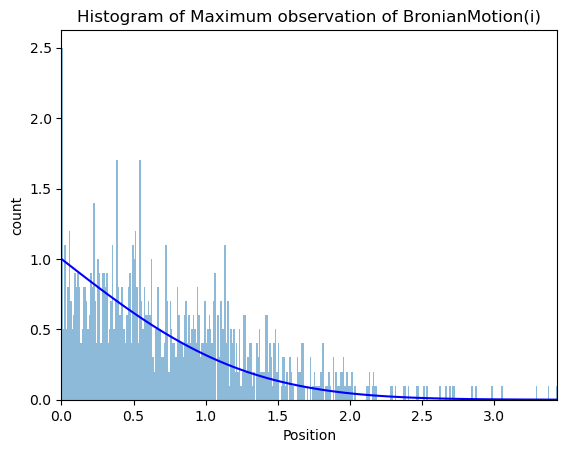

In [46]:
maxList = np.array([])

for i in range(N):
    maxList = np.append(maxList, max(observations[i]))

maxList

bins = np.arange(-10, 10, 0.01) # fixed bin size


x_funktion = np.linspace(0, max(maxList),100)
y_funktion = 2*stats.norm.cdf(-x_funktion/np.sqrt(T))


plt.xlim([min(maxList), max(maxList)])

plt.plot(x_funktion, y_funktion, color='blue', label='C(x,t)')

plt.hist(maxList, bins=bins, density=True, alpha=0.5)
plt.title('Histogram of Maximum observation of BronianMotion(i)')
plt.xlabel('Position')
plt.ylabel('count')

plt.show()

#### 3

ValueError: x and y must have same first dimension, but have shapes (100,) and (1,)

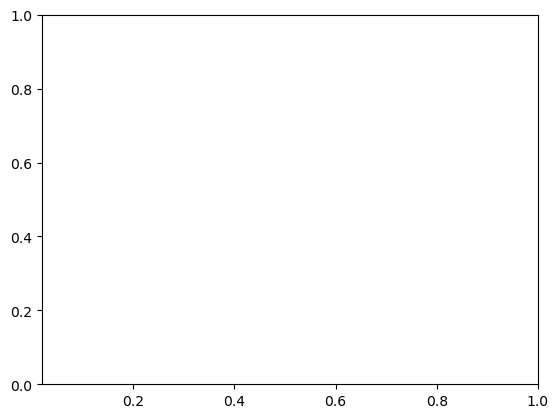

In [47]:
HT = np.array([])

b = 0.5

for i in range(len(observations)):

    minn = 1

    for j in range(len(observations[0])):

        if observations[i][j] >= b:
            minn = partition[j]
            break


    HT = np.append(HT, minn)

bins = np.arange(0, 1.05, 0.05)


x_funktion = np.linspace(0, 1,100)

y_funktion = b * T**(-3/2) * stats.norm.cdf(b/np.sqrt(T))

plt.xlim([min(HT), max(HT)])

plt.plot(x_funktion, y_funktion, color='blue', label='C(x,t)')

plt.hist(HT, bins=bins, density=True, alpha=0.5)
plt.title('Histogram of Maximum observation of BronianMotion(i)')
plt.xlabel('Position')
plt.ylabel('count')

plt.show()

In [ ]:
HT

array([0.50027408, 1.        , 1.        , ..., 1.        , 0.50573011,
       0.50034145])

## Basic Martingales

### Exercise 4

$$E [B_{t}^{2}-t]=-t +E [B_{t}^{2}]=-t +\int_{-\infty}^{\infty}\frac{1}{\sqrt{t}\cdot \sqrt{2\cdot \pi}}\cdot \exp (-\frac{x^{2}}{2\cdot \sqrt{\mathrm{t}}^{2}})\cdot x^{2}d x =-t +t =0$$

### Exercise 5

We assume that $E[X]< \infty $ And we want to show that the process gives as $\mathrm{M}_{t}=E [X | F_{t}]$ is a martingale. here we let ${\{F_{t}\colon t \ge 0\}}$ be a filtration on the process $M_t$.

